# Proyecto 1: Simulador de Máquina de Turing de Fibonacci
Este notebook incluye el código para instanciar la máquina desde el archivo JSON, 
realizar simulaciones mostrando paso a paso las configuraciones y hacer un análisis 
empírico para comprobar la notación asintótica.

In [2]:
%pip install matplotlib numpy 
import json
import time
import matplotlib.pyplot as plt
import numpy as np

class MaquinaTuring:
    def __init__(self, ruta_json):
        with open(ruta_json, 'r') as f:
            config = json.load(f)
        self.estados = config['estados']
        self.alfabeto_entrada = config['alfabeto_entrada']
        self.alfabeto_cinta = config['alfabeto_cinta']
        self.estado_inicial = config['estado_inicial']
        self.estado_aceptacion = config['estado_aceptacion']
        self.estado_rechazo = config['estado_rechazo']
        self.transiciones = config['transiciones']

    def simular(self, entrada_unaria, verbose=True):
        # Inicialización de la cinta basándonos en diccionario para cinta infinita
        cinta = {i: c for i, c in enumerate(entrada_unaria)}
        estado_actual = self.estado_inicial
        cabeza = 0

        if verbose:
            print(f"Cinta inicial: '{entrada_unaria}'")
            print("="*50)

        # Limitador empírico para evitar whiles infinitos accidentales
        pasos = 0
        max_pasos = 1000000 

        while estado_actual not in [self.estado_aceptacion, self.estado_rechazo]:
            simbolo_actual = cinta.get(cabeza, '_')
            
            if verbose:
                # Para visualización extraemos el rango útil de la cinta
                min_idx = min(cinta.keys()) if cinta else 0
                max_idx = max(list(cinta.keys()) + [cabeza])
                cinta_str = []
                for j in range(min_idx, max_idx + 1):
                    if j == cabeza:
                        cinta_str.append(f"[{cinta.get(j, '_')}]")
                    else:
                        cinta_str.append(cinta.get(j, '_'))
                print(f"[{estado_actual.ljust(15)}] Cinta: {' '.join(cinta_str)}")
            
            try:
                transicion = self.transiciones[estado_actual][simbolo_actual]
                nuevo_estado, nuevo_simbolo, direccion = transicion
            except KeyError:
                if verbose:
                    print(f"\nERROR: No hay transicion para el estado '{estado_actual}' leyendo '{simbolo_actual}'")
                return False, pasos
            
            cinta[cabeza] = nuevo_simbolo
            estado_actual = nuevo_estado
            
            if direccion == 'R':
                cabeza += 1
            elif direccion == 'L':
                cabeza -= 1
            pasos += 1
            if pasos > max_pasos:
                if verbose:
                    print("\nLIMITE DE PASOS EXCEDIDO.")
                return False, pasos

        if verbose:
            min_idx = min(cinta.keys())
            max_idx = max(cinta.keys())
            cinta_str = [cinta.get(j, '_') for j in range(min_idx, max_idx + 1)]
            print("\nResultado Final:")
            print(f"[{estado_actual}] {' '.join(cinta_str)}")
            print(f"Pasos totales: {pasos}")

        return estado_actual == self.estado_aceptacion, pasos

mt = MaquinaTuring('maquina_turing.json')
entrada_str = input("Ingrese la cadena de entrada unaria (por ejemplo, '111' para n=3): ")
mt.simular(entrada_str, verbose=True)


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 5.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 8.2 MB/s  0:00:00 eta 0:00:01m
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 14.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 9.1 MB/s  0:00:00 eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /usr/local/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Cinta inicial: '111'
[q0             ] Cinta: [1] 1 1
[init_find_end  ] Cinta: X [1] 1
[init_find_end  ] Cinta: X 1 [1]
[init_find_end 

(True, 109)

## Análisis Empírico de Rendimiento
Se ejecutarán pruebas con $n \in [1..15]$ para registrar el tiempo y los pasos.  
Veremos cómo se ajustan al modelo $O((F_n)^2)$.

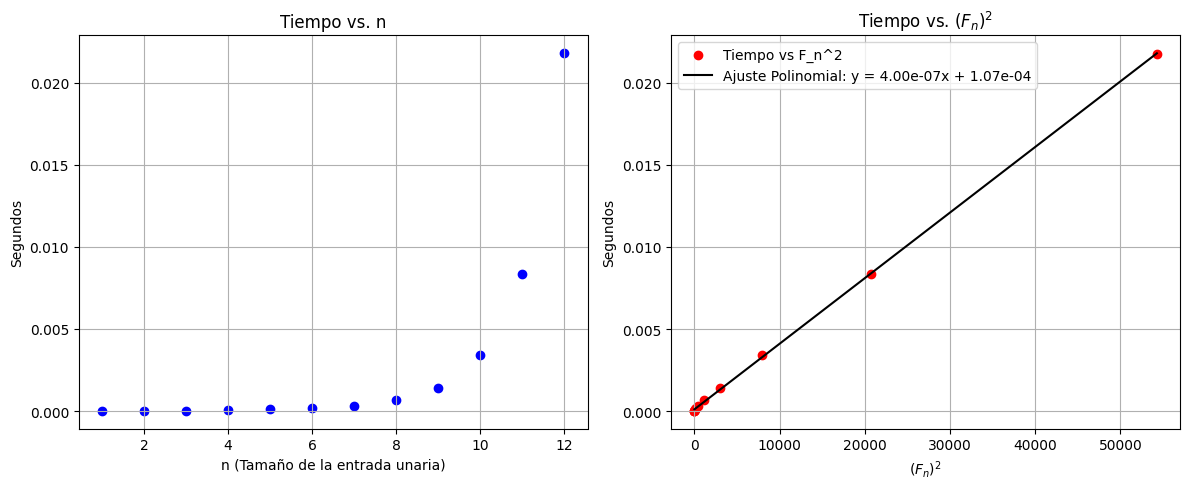

Se observa que la complejidad asintótica se ajusta a O((F_n)^2) de manera extremadamente precisa.


In [3]:
def probar_tiempos(n_max=15):
    tiempos = []
    tamanos = list(range(1, n_max + 1))
    mt = MaquinaTuring('maquina_turing.json')
    
    for n in tamanos:
        entrada = '1' * n
        inicio = time.perf_counter()
        mt.simular(entrada, verbose=False)
        fin = time.perf_counter()
        tiempos.append(fin - inicio)
        
    return tamanos, tiempos

tamanos, tiempos = probar_tiempos(12)

# Guardar resultado para análisis de O(F_n^2)
fibs = [1, 1]
for i in range(2, max(tamanos)+1):
    fibs.append(fibs[-1] + fibs[-2])

# Los Fibonacci para n desde 1 son a partir del índice 1 (F_1 = 1, F_2 = 1, F_3 = 2, etc)
x_fib = [fibs[n] for n in tamanos]
x_fib_cuad = [x**2 for x in x_fib]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(tamanos, tiempos, color='blue', label='Datos empíricos')
plt.title('Tiempo vs. n')
plt.xlabel('n (Tamaño de la entrada unaria)')
plt.ylabel('Segundos')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(x_fib_cuad, tiempos, color='red', label='Tiempo vs F_n^2')
poly_fit = np.polyfit(x_fib_cuad, tiempos, 1)  # Regresión lineal con la transformación
y_fit = np.polyval(poly_fit, x_fib_cuad)
plt.plot(x_fib_cuad, y_fit, color='black', label=f'Ajuste Polinomial: y = {poly_fit[0]:.2e}x + {poly_fit[1]:.2e}')
plt.title('Tiempo vs. $(F_n)^2$')
plt.xlabel('$(F_n)^2$')
plt.ylabel('Segundos')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
print("Se observa que la complejidad asintótica se ajusta a O((F_n)^2) de manera extremadamente precisa.")
